# KDEGlyph

`KDEGlyph` evaluates an isotropic Gaussian kernel-density estimate of an `(x, y)` point cloud on a grid (NumPy only, no scipy) and draws it as filled (`shade=True`, default) or line density contours.

In [1]:
%matplotlib inline
import numpy as np

from cleopatra.kde_glyph import KDEGlyph

rng = np.random.default_rng(0)
x = np.concatenate([rng.normal(-1, 0.6, 400), rng.normal(1.5, 0.5, 300)])
y = np.concatenate([rng.normal(0, 0.6, 400), rng.normal(1.0, 0.5, 300)])

## 1. Filled density contours

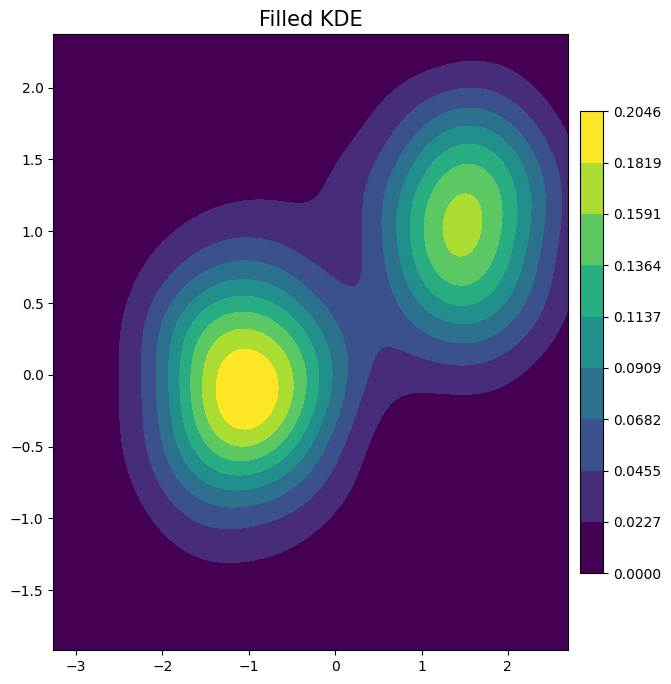

In [2]:
kde = KDEGlyph(x, y, cmap='viridis')
fig, ax, cs = kde.plot(title='Filled KDE')

## 2. Line contours with a wider kernel

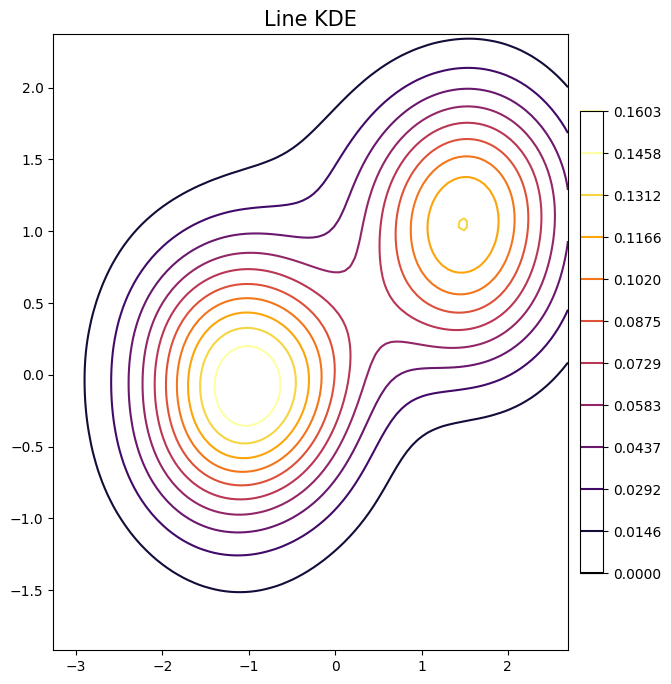

In [3]:
kde = KDEGlyph(x, y, shade=False, bw_method=1.4, levels=12, cmap='inferno')
fig, ax, cs = kde.plot(title='Line KDE')

## 3. Relief-shaded density surface (hillshade)

A kernel-density estimate is itself a smooth surface -- `z = density` -- so `hillshade` can shade it like a
DEM, making the density peaks and ridges stand out. It renders the density as a relief-shaded image (with the
colorbar on a proxy mappable) instead of contour bands. It is the same `hillshade` option as the other
surface glyphs, reusing the raster (`shade_grid`) geometry on the density grid.

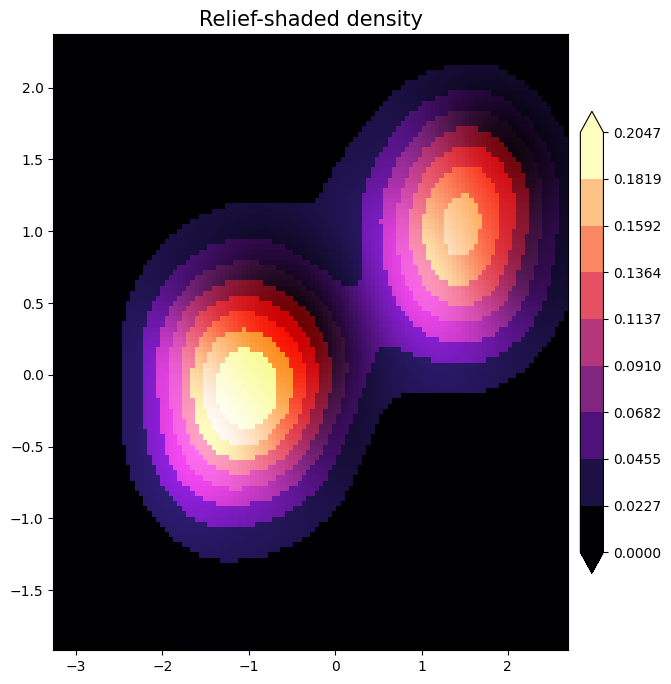

In [4]:
kde = KDEGlyph(x, y, cmap='magma', gridsize=120, hillshade={'vert_exag': 25})
fig, ax, im = kde.plot(title='Relief-shaded density')

The two clusters read as shaded 'hills' -- the taller, denser peak clearly rising above the smaller one --
which a flat colour ramp alone would not convey as vividly.

## Data-style presets: `style=` and `apply_style()`

Colour the density with a named preset. `style=` works at construction or `plot()` time; `apply_style(name)` restyles the glyph **in place** and `glyph.style` reads it back. The preset is sticky (a later plain `plot()` keeps it) and clearable (`plot(style=None)`). Only continuous presets apply -- a categorical preset is rejected, since a density is continuous.

style: temperature
style after apply_style: precipitation


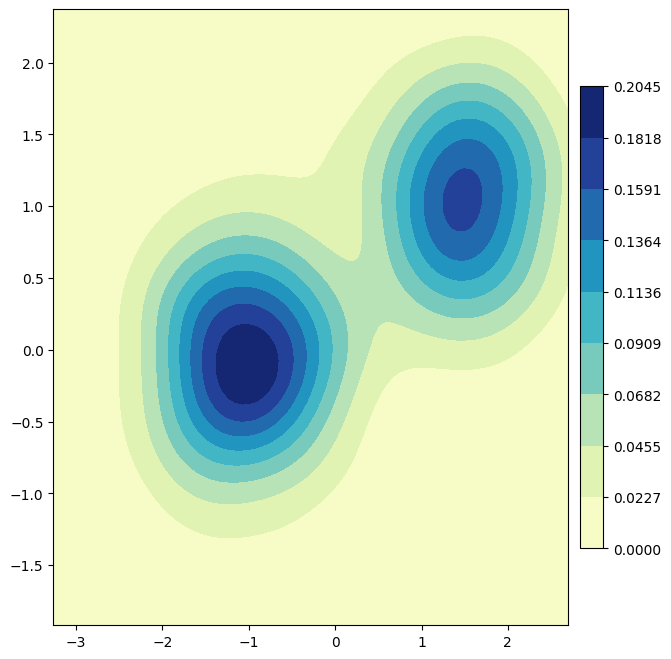

In [5]:
kde = KDEGlyph(x, y, gridsize=80)
kde.plot(style='temperature')
print('style:', kde.style)

kde.apply_style('precipitation')  # restyle the density in place
print('style after apply_style:', kde.style)